In [1]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.datasets import cifar10
import numpy as np
import matplotlib.pyplot as plt

In [2]:
print("Loading and preprocessing CIFAR-10 data...")
# We only need the images, so we can discard the labels with '_'
(x_train, _), (x_test, _) = cifar10.load_data()

# Normalize pixel values to be between 0 and 1
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")

Loading and preprocessing CIFAR-10 data...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
x_train shape: (50000, 32, 32, 3)
x_test shape: (10000, 32, 32, 3)


In [3]:
def add_noise(array):
    """Adds random Gaussian noise to each image in the supplied array."""
    noise_factor = 0.3  # we can adjust this to control the noise level
    noisy_array = array + noise_factor * np.random.normal(
        loc=0.0, scale=1.0, size=array.shape
    )
    # Clip the values to be between 0 and 1
    return np.clip(noisy_array, 0.0, 1.0)


def display_images(array1, array2):
    """Displays ten random images from each of the two arrays."""
    n = 10
    indices = np.random.randint(len(array1), size=n)
    images1 = array1[indices, :]
    images2 = array2[indices, :]

    plt.figure(figsize=(20, 4))
    for i, (image1, image2) in enumerate(zip(images1, images2)):
        # Display original noisy images
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(image1)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

        # Display denoised images
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(image2)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    plt.suptitle("Top Row: Noisy Images | Bottom Row: Denoised by Autoencoder", fontsize=16)
    plt.show()


Creating noisy versions of the dataset...
Displaying a sample of original vs. noisy images:


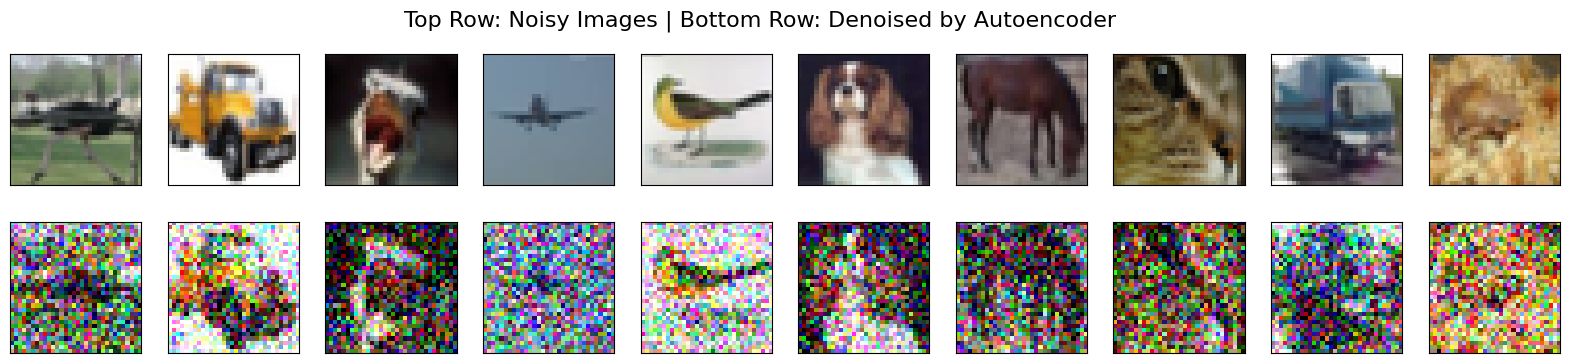

In [4]:
print("\nCreating noisy versions of the dataset...")
noisy_x_train = add_noise(x_train)
noisy_x_test = add_noise(x_test)

print("Displaying a sample of original vs. noisy images:")
display_images(x_test, noisy_x_test)

In [5]:
print("\nBuilding the Denoising Autoencoder model...")

# --- Input Layer ---
input_layer = Input(shape=(32, 32, 3))

# --- Encoder ---
# This part of the model learns to compress the image into a smaller representation.
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_layer)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x) # Bottleneck: The encoded representation

# --- Decoder ---
# This part learns to reconstruct the original image from the compressed representation.
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x) # Final output

# --- Create the Autoencoder Model ---
autoencoder = Model(input_layer, decoded)
autoencoder.summary()


Building the Denoising Autoencoder model...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
print("\nCompiling and training the model...")
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

autoencoder.fit(
    noisy_x_train,  # Input: noisy images
    x_train,        # Target: clean images
    epochs=30,      # Increased epochs for better denoising
    batch_size=128,
    shuffle=True,
    validation_data=(noisy_x_test, x_test)
)



Compiling and training the model...
Epoch 1/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - loss: 0.0201 - val_loss: 0.0095
Epoch 2/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 0.0093 - val_loss: 0.0087
Epoch 3/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0085 - val_loss: 0.0081
Epoch 4/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0081 - val_loss: 0.0078
Epoch 5/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0078 - val_loss: 0.0075
Epoch 6/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0076 - val_loss: 0.0074
Epoch 7/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0074 - val_loss: 0.0072
Epoch 8/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0072 - val_loss: 0.0072
Epoch 9/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0071 - val_loss: 0.0070
Epoch 10/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0070 - val_loss: 0.0070
Epoch 11/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0069 - val_loss: 0.0070
Epoch 


Predicting on noisy test images to see the denoised results...
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


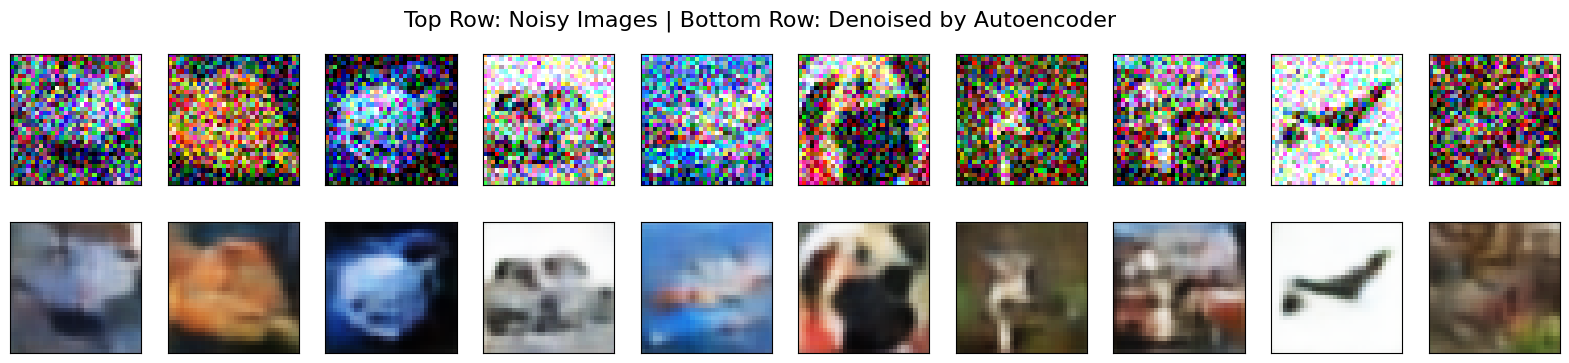

In [7]:
print("\nPredicting on noisy test images to see the denoised results...")
denoised_images = autoencoder.predict(noisy_x_test)

# Display the noisy inputs and the denoised outputs
display_images(noisy_x_test, denoised_images)